In [143]:
!pip install nbformat

In [122]:
import pandas as pd
import numpy as np

In [56]:
u='https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day24-standardization/Social_Network_Ads.csv'

In [59]:
df=pd.read_csv(u)

In [60]:
df.head(2)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0


In [61]:
df=df.iloc[:,2:]

In [62]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((280, 2), (120, 2))

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [64]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [65]:
X_train

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [66]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [67]:
np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [68]:
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


In [69]:
import seaborn as sns

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

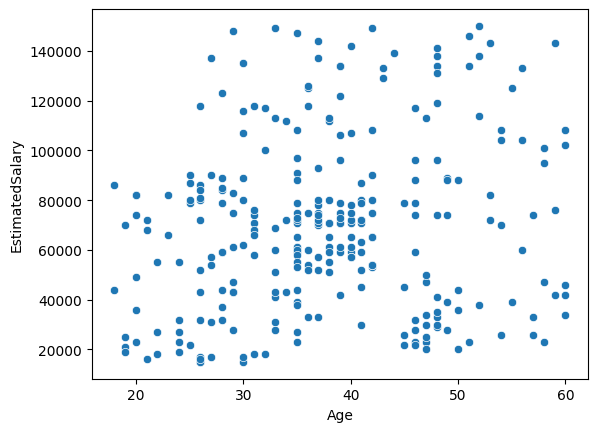

In [73]:
sns.scatterplot(x=X_train['Age'], y=X_train['EstimatedSalary'])

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

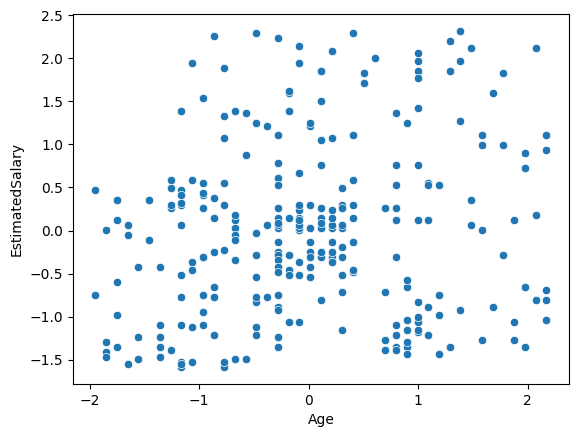

In [74]:
sns.scatterplot(x=X_train_scaled['Age'], y=X_train_scaled['EstimatedSalary'])

In [75]:
import matplotlib as plt

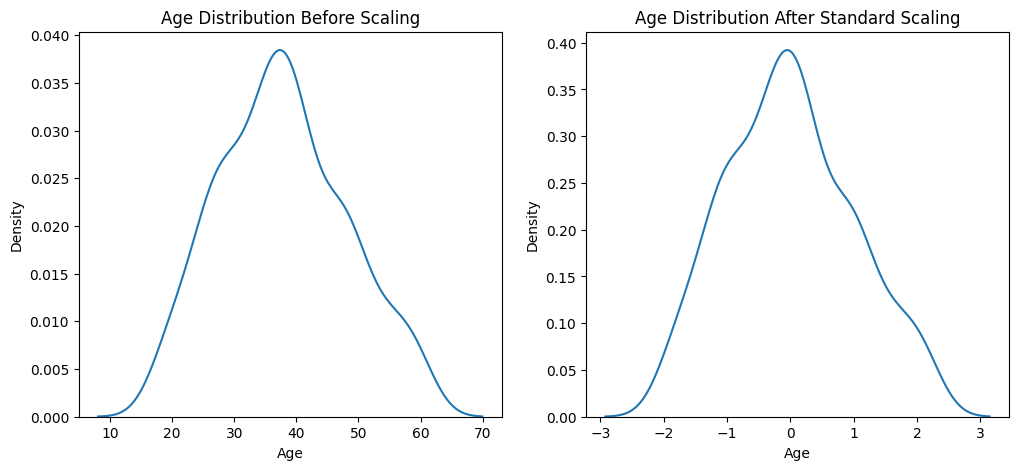

In [78]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)

# after scaling
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
plt.show()

In [83]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
lr = LinearRegression()          # Original data
lr_scaled = LinearRegression()   # Scaled data
lr.fit(X_train, y_train)
lr_scaled.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

# Print predictions
#print("Predictions on original data:", y_pred)
#print("Predictions on scaled data:", y_pred_scaled)
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [84]:
from sklearn.metrics import accuracy_score

In [86]:
from sklearn.metrics import mean_squared_error, r2_score

# For original data
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Original data -> MSE:", mse, "R2:", r2)

# For scaled data
mse_scaled = mean_squared_error(y_test, y_pred_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)
print("Scaled data -> MSE:", mse_scaled, "R2:", r2_scaled)


Original data -> MSE: 0.10892532150340756 R2: 0.5157379964034983
Scaled data -> MSE: 0.10892532150340756 R2: 0.5157379964034983


In [90]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr_scaled = LogisticRegression()
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

LogisticRegression()

In [91]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)
from sklearn.metrics import accuracy_score
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667


In [92]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()
dt.fit(X_train,y_train)
dt_scaled.fit(X_train_scaled,y_train)

DecisionTreeClassifier()

In [93]:
y_pred = dt.predict(X_test)
y_pred_scaled = dt_scaled.predict(X_test_scaled)
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Scaled 0.875


In [96]:
d1=sns.load_dataset('iris')
#d2=sns.load_dataset('titanic)
d3=sns.load_dataset('tips')
d4=sns.load_dataset('planets')
d5=sns.load_dataset('mpg')

In [97]:
d1.head(2)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa


In [99]:
d3.head(2)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3


In [105]:
y=d3.iloc[:,6]

In [106]:
y.head(2)

,size
0,2
1,3


In [107]:
x=d3.iloc[:,:2]

In [108]:
x.head(2)

,total_bill,tip
0,16.99,1.01
1,10.34,1.66


<Axes: xlabel='total_bill', ylabel='Density'>

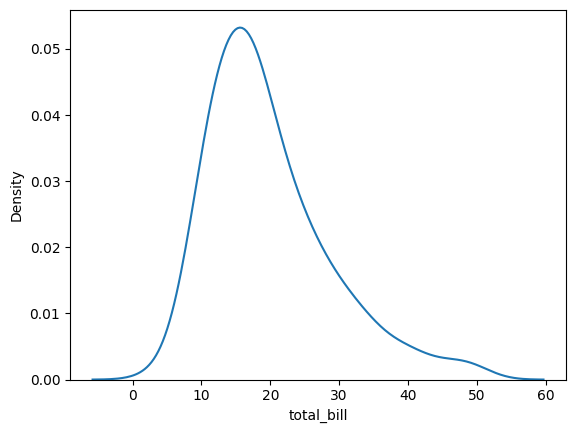

In [110]:
sns.kdeplot(x['total_bill'])

<Axes: xlabel='tip', ylabel='Density'>

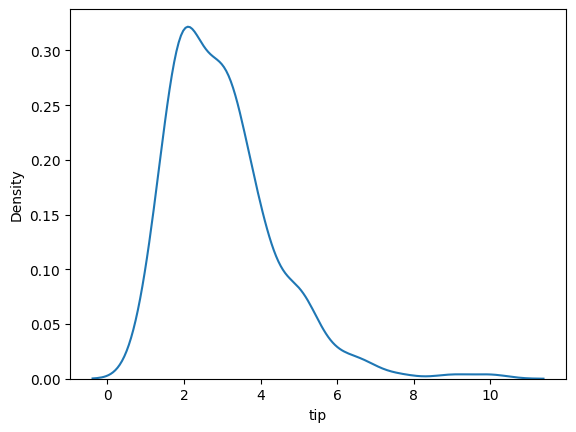

In [112]:
sns.kdeplot(x['tip'])

In [114]:
y.unique()

array([2, 3, 4, 1, 6, 5])

<Axes: xlabel='total_bill', ylabel='tip'>

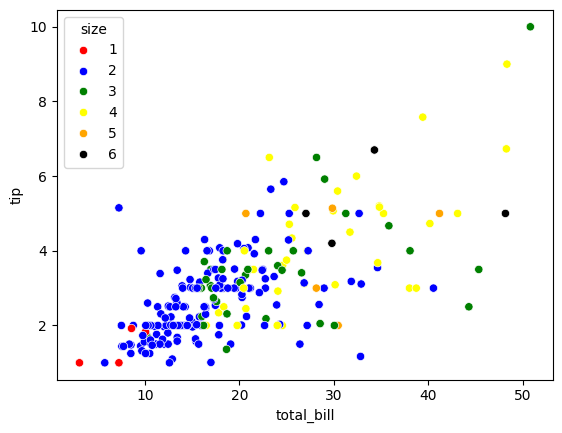

In [117]:
color_dict = {1:'red', 2:'blue', 3:'green', 4:'yellow', 5:'orange', 6:'black'}

sns.scatterplot(x=x['total_bill'], y=x['tip'], hue=y, palette=color_dict)

In [118]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((170, 2), (74, 2))

In [119]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [120]:
np.round(X_train.describe(), 1)

,total_bill,tip
count,170.0,170.0
mean,20.0,3.0
std,9.1,1.4
min,3.1,1.0
25%,13.2,2.0
50%,18.0,2.7
75%,24.1,3.5
max,50.8,10.0


In [124]:
np.round(pd.DataFrame(X_train_scaled, columns=X_train.columns).describe(), 1)

,total_bill,tip
count,170.0,170.0
mean,0.4,0.2
std,0.2,0.2
min,0.0,0.0
25%,0.2,0.1
50%,0.3,0.2
75%,0.4,0.3
max,1.0,1.0


In [126]:
import matplotlib.pyplot as plt

<Axes: xlabel='total_bill', ylabel='tip'>

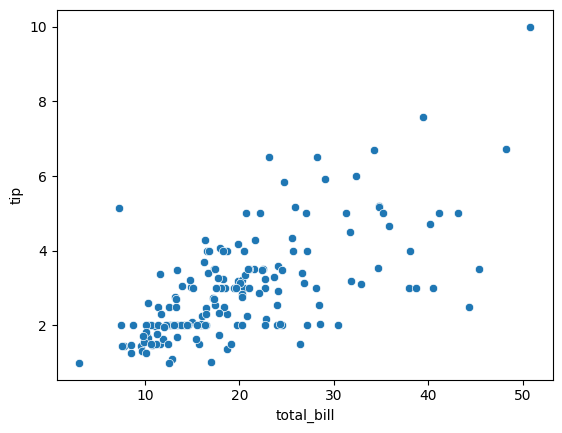

In [134]:
sns.scatterplot(x=X_train['total_bill'], y=X_train['tip'])

<Axes: xlabel='total_bill', ylabel='tip'>

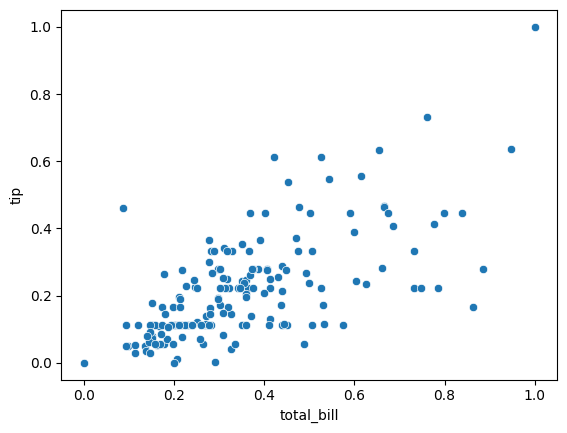

In [136]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
sns.scatterplot(x=X_train_scaled_df['total_bill'], y=X_train_scaled_df['tip'])

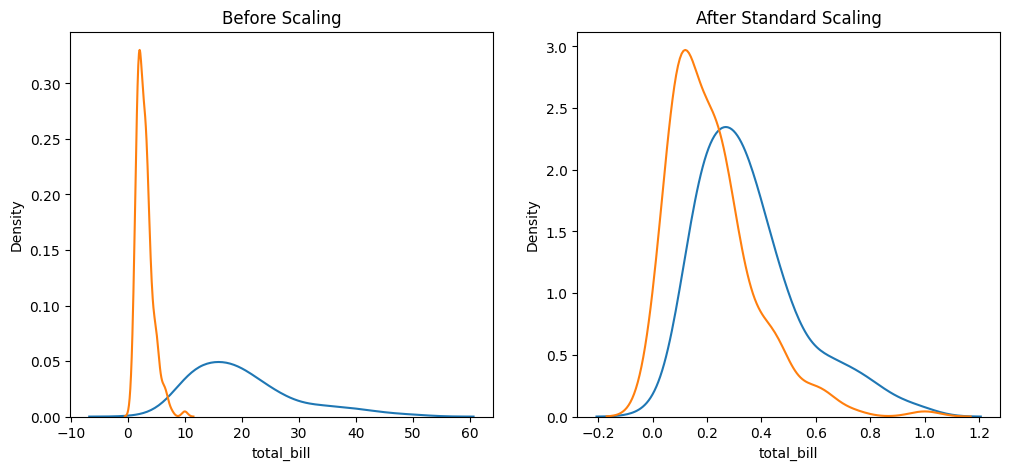

In [139]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['total_bill'], ax=ax1)
sns.kdeplot(X_train['tip'], ax=ax1)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled_df['total_bill'], ax=ax2)
sns.kdeplot(X_train_scaled_df['tip'], ax=ax2)
plt.show()

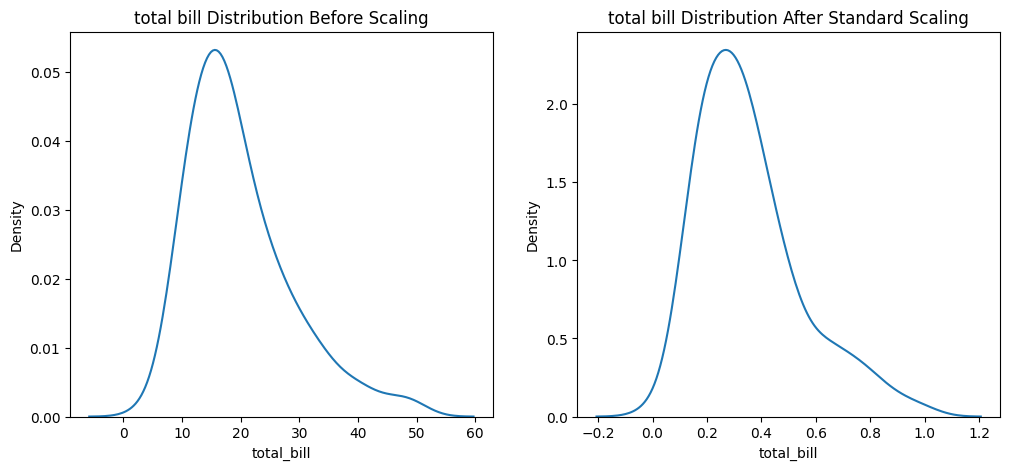

In [141]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('total bill Distribution Before Scaling')
sns.kdeplot(X_train['total_bill'], ax=ax1)

# after scaling
ax2.set_title('total bill Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled_df['total_bill'], ax=ax2)
plt.show()

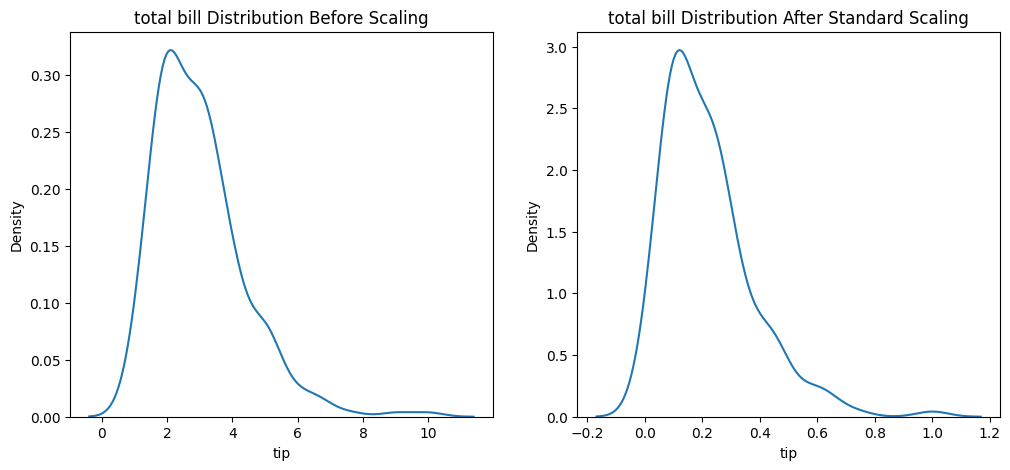

In [142]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('total bill Distribution Before Scaling')
sns.kdeplot(X_train['tip'], ax=ax1)

# after scaling
ax2.set_title('total bill Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled_df['tip'], ax=ax2)
plt.show()